<a href="https://colab.research.google.com/github/Namesakenberg/BrickByBrickML/blob/main/Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.max_colwidth',None)

In [104]:
df = pd.read_csv('/content/gurgaon_properties_missing_value_imputation.csv')

In [105]:
df.shape

(3554, 18)

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3554 entries, 0 to 3553
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3554 non-null   object 
 1   society          3554 non-null   object 
 2   sector           3554 non-null   object 
 3   price            3554 non-null   float64
 4   price_per_sqft   3554 non-null   float64
 5   bedRoom          3554 non-null   float64
 6   bathroom         3554 non-null   float64
 7   balcony          3554 non-null   object 
 8   floorNum         3554 non-null   float64
 9   agePossession    3554 non-null   object 
 10  built_up_area    3554 non-null   float64
 11  study room       3554 non-null   float64
 12  servant room     3554 non-null   float64
 13  store room       3554 non-null   float64
 14  pooja room       3554 non-null   float64
 15  others           3554 non-null   float64
 16  furnishing_type  3554 non-null   float64
 17  luxury_score  

In [107]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [108]:
# remove society as the user wont input the name of the society , he would input the sector name
# also drop the price per sqft column , as user wont enter the price per sqft for a particular area
train_df = df.drop(columns = ['society' , 'price_per_sqft'])

In [109]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


<Axes: >

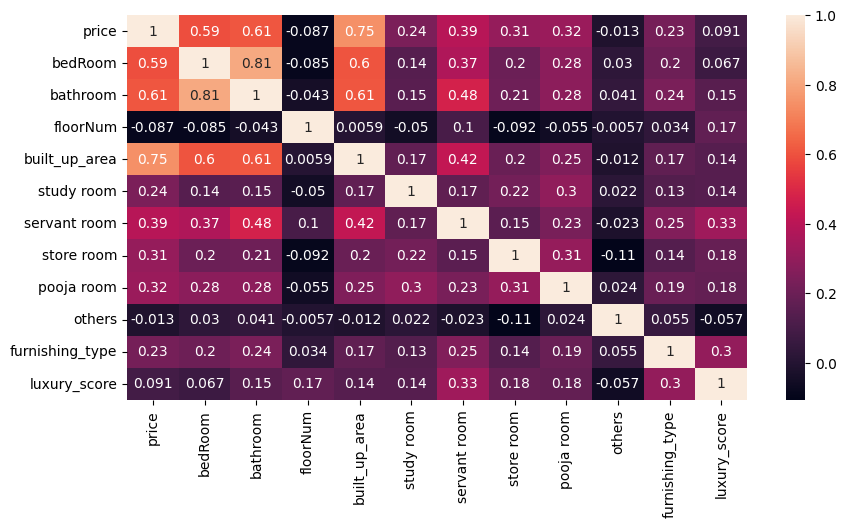

In [110]:
plt.figure(figsize=(10,5))
sns.heatmap(train_df.select_dtypes(include='number').corr(),annot=True)

In [111]:
# get the correlation of every column wrt to the price

train_df.select_dtypes(include = 'number').corr()['price'].sort_values(ascending=False)

,price
price,1.000000
built_up_area,0.748574
bathroom,0.609777
bedRoom,0.591289
servant room,0.391930
pooja room,0.319852
store room,0.305677
study room,0.242955
furnishing_type,0.225625
luxury_score,0.091473


In [112]:
# main objective of feature selection is to only keep the columns which will be helpful in predicting the price of the properties
# as the user will provide the information of the house he wants and the price will be predicted

# Luxury Score :
we cannot ask the user to enter the luxury score of the property in the numerical form , thus we would make the categories of the luxury level on the basis of the scores like (budget , semiluxury , luxury)

<Axes: xlabel='luxury_score', ylabel='Density'>

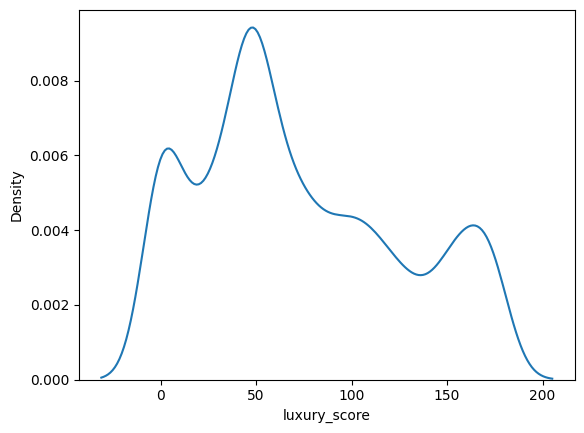

In [113]:
sns.kdeplot(df['luxury_score'])

<Axes: xlabel='luxury_score'>

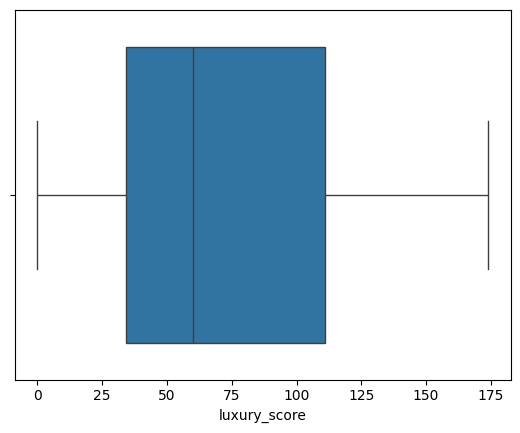

In [114]:
sns.boxplot(x = df['luxury_score'])

In [115]:
# low -> lower than 50
# medium -> 50 - 150
# high -> 150 +

def luxury_category(score):
  if score <=50:
    return "Low"
  elif score>50 and score<150:
    return "Medium"
  elif score>150 :
    return "High"
  else:
    return None

train_df['luxury_category'] = train_df['luxury_score'].apply(luxury_category)

In [116]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,Low
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,Low
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,Low
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,High
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,High


## floor Num

In [117]:
train_df['floorNum'].describe()

,floorNum
count,3554.000000
mean,6.887451
std,6.062694
min,0.000000
25%,2.000000
50%,5.000000
75%,10.000000
max,51.000000


<Axes: xlabel='floorNum'>

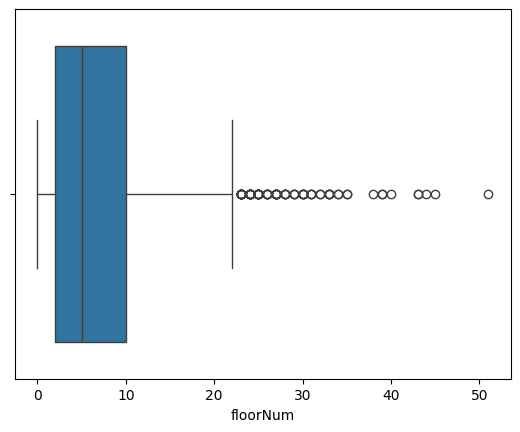

In [118]:
sns.boxplot(x=train_df['floorNum'])

In [119]:
def floor_category(floor):
  if floor <= 2 :
    return "Low Rise"
  elif floor>=3 and floor<=10:
    return "Mid Rise"
  elif floor>=11 :
    return "High Rise"
  else:
    return None


train_df['floorNum_category'] = train_df['floorNum'].apply(floor_category)

In [120]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floorNum_category
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,Low,Low Rise
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,Low,Mid Rise
2,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,Low,High Rise
3,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,High,Mid Rise
4,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,High,Mid Rise


In [121]:
train_df = train_df.drop(columns=['luxury_score' ,'floorNum'])

In [122]:
# convert all the text categories into numerical categories
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
data_label_encoded = train_df.copy()    # copy the dataframe
categorical_columns = data_label_encoded.select_dtypes(include=['object']).columns  # select the categorical columns
for col in categorical_columns:
  data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])    # aplly oridanl encoding
  print(oe.categories_)                                                    # print the categories
x_label = data_label_encoded.drop(columns=['price'])                    # x = all other columns expert price
y_label = data_label_encoded['price']                                   # y = target column = price

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 10', 'sector 102', 'sector 103', 'sector 104',
       'sector 105', 'sector 106', 'sector 107', 'sector 108',
       'sector 109', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 30', 'sector 31', 'sector 33',
       'sector 36', 'sector 37', 'sector 37d', 'sector 38', 'sector 39',
       'sector 4', 'sector 40', 'sector 41', 'sector 43', 'sector 45',
       'sector 46', 'sector 47', 'sector 48', 'sector 49', 'sector 5',
       'sector 50', 'sector 51', 'sector 52', 'sector 53', 'sector 54',
       'sector 55', 'sector 56', 'sector 57', 'sector 58', 'sector 59',
       'sector 6', 'sector 60', 'sector 61', 'sector 62', 

# since ordinal encoding is used , the categories are number , thus linear models wont understand the data properly and wont give proper results.

## thus avoid linear models

In [123]:
data_label_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3554 entries, 0 to 3553
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   property_type      3554 non-null   float64
 1   sector             3554 non-null   float64
 2   price              3554 non-null   float64
 3   bedRoom            3554 non-null   float64
 4   bathroom           3554 non-null   float64
 5   balcony            3554 non-null   float64
 6   agePossession      3554 non-null   float64
 7   built_up_area      3554 non-null   float64
 8   study room         3554 non-null   float64
 9   servant room       3554 non-null   float64
 10  store room         3554 non-null   float64
 11  pooja room         3554 non-null   float64
 12  others             3554 non-null   float64
 13  furnishing_type    3554 non-null   float64
 14  luxury_category    3554 non-null   float64
 15  floorNum_category  3554 non-null   float64
dtypes: float64(16)
memory us

In [124]:
x_label.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floorNum_category
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0


In [125]:
y_label.head()

,price
0,0.82
1,0.95
2,0.32
3,1.60
4,0.48


# feature selection

8 techniques will be applied , each technique will give a score to all the columns.
thus every feature will have 8 scores , at the end we will take the average of all the 8 scores
the feature with the highest scores will be of the highest importance
and the features with the lowest scores will have the lowest importance

## 1) correlation analysis

<Axes: >

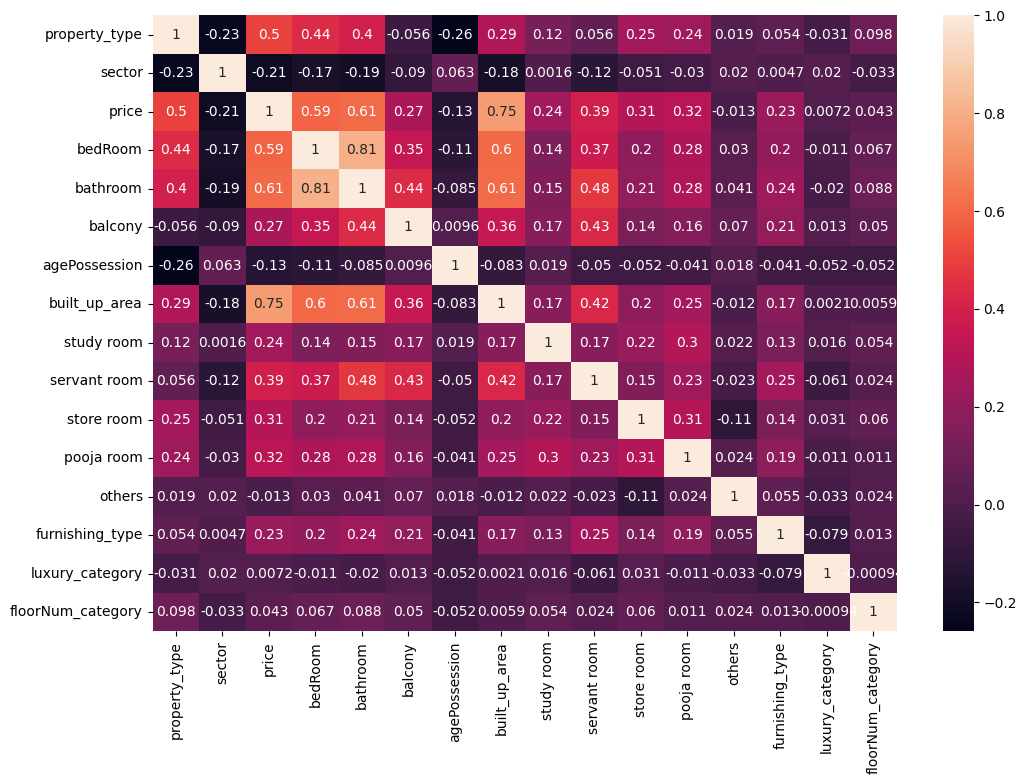

In [126]:
plt.figure(figsize=(12,8))
sns.heatmap(data_label_encoded.corr(),annot=True)

In [127]:
correlation_score = pd.DataFrame({
    'feature': x_label.columns,
    'corr_score': data_label_encoded.corr()['price'].loc[x_label.columns].values
}).sort_values(by='corr_score', ascending=False)


## 2) Embedded techique: train a random forest regressor to get the highest feature importance

In [128]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100 , random_state=42)
rf.fit(x_label,y_label)
feature_importance_rf= pd.DataFrame({'feature' : x_label.columns , 'rf_importance' : rf.feature_importances_}).sort_values(by='rf_importance',ascending=False)

In [129]:
feature_importance_rf

,feature,rf_importance
6,built_up_area,0.650578
1,sector,0.102284
0,property_type,0.100186
3,bathroom,0.026437
2,bedRoom,0.023328
8,servant room,0.019136
5,agePossession,0.014640
4,balcony,0.012842
12,furnishing_type,0.009889
7,study room,0.008803


## 3) Do the same using gradient boosting

In [130]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor()
gb.fit(x_label , y_label)

feature_importance_gb = pd.DataFrame({'feature':x_label.columns , 'gb_importance':gb.feature_importances_}).sort_values(by='gb_importance',ascending=False)

feature_importance_gb

,feature,gb_importance
6,built_up_area,0.677732
1,sector,0.103121
0,property_type,0.098420
2,bedRoom,0.037920
3,bathroom,0.036297
8,servant room,0.023195
9,store room,0.010357
5,agePossession,0.004222
7,study room,0.003114
12,furnishing_type,0.002760


## 4) permutation importance

In [131]:
# an approach in which a model is trained on all the columns initially , then for
# every column individually the data in the columns is jumbled / shuffled ,and another model is trained.
# if the accuracy btw 2 outputs is reduced then the column is important
# else it is not , thus on the basis of the ddifference in the accuracy a score will be given to the column


# thus we train a random forest on all the data , now for every row individually shuffle the data ,
#  train new model on updated data and check the difference in the accuracy. if

In [132]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

x_train_label, x_test_label,y_train_label , y_test_label, = train_test_split(x_label,y_label,test_size=0.2,random_state=42)
rf.fit(x_train_label , y_train_label)
perm_importance = permutation_importance(rf , x_test_label , y_test_label , n_repeats=30 , random_state=42)

feature_importance_permu = pd.DataFrame({'feature':x_label.columns ,
                                         'permutation_importance':perm_importance.importances_mean}).sort_values(by='permutation_importance',ascending=False)
feature_importance_permu

,feature,permutation_importance
6,built_up_area,0.735368
0,property_type,0.201614
1,sector,0.180029
8,servant room,0.023303
3,bathroom,0.023145
2,bedRoom,0.023107
5,agePossession,0.006150
9,store room,0.001556
14,floorNum_category,0.001422
10,pooja room,0.000941


## Lasso

expected to give bad results still trying it out (LoL !)

In [133]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_scaled = sc.fit_transform(x_label)

lasso = Lasso(alpha = 0.01 , random_state = 42)
lasso.fit(x_scaled , y_label)

feature_importance_lasso= pd.DataFrame({'feature':x_label.columns ,
                                         'lasso_score':lasso.coef_}).sort_values(by='lasso_score',ascending=False)
feature_importance_lasso

,feature,lasso_score
6,built_up_area,1.510363
0,property_type,0.714199
3,bathroom,0.275228
9,store room,0.199749
7,study room,0.171736
12,furnishing_type,0.163402
8,servant room,0.160348
10,pooja room,0.073480
13,luxury_category,0.050587
2,bedRoom,0.014327


In [134]:
# results are shit , sector is one of the most important column

## recusrsive feature selection

In [135]:
from sklearn.feature_selection import RFE

estimator = RandomForestRegressor()
rfe = RFE(estimator, n_features_to_select=x_label.shape[1],step=1)
rfe = rfe.fit(x_label , y_label)

selected_features = x_label.columns[rfe.support_]
feature_scores = rfe.estimator_.feature_importances_
feature_importance_recursive= pd.DataFrame({'feature':x_label.columns ,
                                         'rfe_score':feature_scores}).sort_values(by='rfe_score',ascending=False)
feature_importance_recursive

,feature,rfe_score
6,built_up_area,0.650695
1,sector,0.102355
0,property_type,0.100863
2,bedRoom,0.025887
3,bathroom,0.024638
8,servant room,0.020001
5,agePossession,0.014193
4,balcony,0.012790
12,furnishing_type,0.011172
9,store room,0.007974


#Linear regression weights

considered using linear models as the heatmap of corr matrix shows some relation between various features

In [136]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_scaled , y_label)

feature_importance_linReg= pd.DataFrame({'feature':x_label.columns ,
                                         'lin_reg_weights':lr.coef_}).sort_values(by='lin_reg_weights',ascending=False)
feature_importance_linReg

,feature,lin_reg_weights
6,built_up_area,1.512819
0,property_type,0.713245
3,bathroom,0.282246
9,store room,0.204234
7,study room,0.179920
12,furnishing_type,0.172398
8,servant room,0.169354
10,pooja room,0.076465
13,luxury_category,0.061814
2,bedRoom,0.016945


In [137]:
# again this is shit

# SHAP : explainable ai

In [138]:
!pip install shap

In [139]:
import shap
rf.fit(x_label , y_label)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_label)
shap_sum = np.abs(shap_values).mean(axis=0)
shap_values

array([[-0.18236819,  0.15011731, -0.03312372, ..., -0.01122079,
        -0.00494802, -0.01020942],
       [-0.19899206, -0.39578577, -0.04665316, ..., -0.01198732,
        -0.00376993, -0.00389276],
       [-0.1766326 , -0.41668795, -0.04458392, ..., -0.01381614,
        -0.0127233 , -0.0175338 ],
       ...,
       [-0.18874552,  0.07195232, -0.00665213, ...,  0.0063954 ,
         0.0154982 , -0.00442835],
       [ 1.52800037,  0.96607624,  0.38248034, ...,  0.09520292,
         0.0316563 ,  0.04771145],
       [-0.31032063,  0.02619186, -0.02350689, ...,  0.00734361,
        -0.00511616,  0.03340511]])

In [140]:
feature_importance_shap = pd.DataFrame({'feature':x_label.columns , 'feature_importance_shap':np.abs(shap_values).mean(axis=0)}).sort_values(by='feature_importance_shap',ascending=False)

feature_importance_shap

,feature,feature_importance_shap
6,built_up_area,1.254809
0,property_type,0.472170
1,sector,0.382302
3,bathroom,0.112737
8,servant room,0.094878
2,bedRoom,0.050069
4,balcony,0.040589
12,furnishing_type,0.027693
5,agePossession,0.027541
14,floorNum_category,0.024283


In [141]:
final_scores  = correlation_score.merge(feature_importance_rf,on='feature').merge(feature_importance_gb,on='feature').merge(feature_importance_permu,on='feature').merge(feature_importance_lasso,on='feature').merge(feature_importance_recursive,on='feature').merge(feature_importance_linReg,on='feature').merge(feature_importance_shap,on='feature')

In [143]:
final_scores

,feature,corr_score,rf_importance,gb_importance,permutation_importance,lasso_score,rfe_score,lin_reg_weights,feature_importance_shap
0,built_up_area,0.748574,0.650578,0.677732,0.735368,1.510363,0.650695,1.512819,1.254809
1,bathroom,0.609777,0.026437,0.036297,0.023145,0.275228,0.024638,0.282246,0.112737
2,bedRoom,0.591289,0.023328,0.037920,0.023107,0.014327,0.025887,0.016945,0.050069
3,property_type,0.503728,0.100186,0.098420,0.201614,0.714199,0.100863,0.713245,0.472170
4,servant room,0.391930,0.019136,0.023195,0.023303,0.160348,0.020001,0.169354,0.094878
5,pooja room,0.319852,0.006535,0.000291,0.000941,0.073480,0.005954,0.076465,0.012431
6,store room,0.305677,0.008254,0.010357,0.001556,0.199749,0.007974,0.204234,0.016957
7,balcony,0.269637,0.012842,0.001771,0.000861,-0.044080,0.012790,-0.067018,0.040589
8,study room,0.242955,0.008803,0.003114,-0.016744,0.171736,0.006923,0.179920,0.019289
9,furnishing_type,0.225625,0.009889,0.002760,-0.007614,0.163402,0.011172,0.172398,0.027693


In [155]:
# Convert 'feature' column to a proper DataFrame
features_col = final_scores['feature'].to_frame()

# Normalize only the numeric columns
numeric_cols = final_scores.drop(columns=['feature'])
normalized_scores = numeric_cols.divide(numeric_cols.sum(axis=0), axis=1)

# Combine the 'feature' column with normalized numeric columns
final_scores = pd.concat([features_col, normalized_scores], axis=1)

In [157]:
final_scores[['rf_importance', 'gb_importance', 'permutation_importance', 'rfe_score', 'feature_importance_shap']].mean(axis=1).sort_values(ascending=False)

,0
0,0.619210
3,0.131162
14,0.122117
1,0.030231
2,0.025279
4,0.023854
13,0.009812
7,0.008800
6,0.006908
9,0.005631


In [150]:
x_label.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floorNum_category
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0


In [152]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100 ,random_state=42)
scores = cross_val_score(rf , x_label , y_label , scoring ='r2',cv=5)
print(scores.mean())

0.8210467573689415


In [159]:
rf = RandomForestRegressor(n_estimators=100 ,random_state=42)
scores = cross_val_score(rf , x_label.drop(columns=['pooja room' , 'study room' ,'others']) , y_label , scoring ='r2',cv=5)
print(scores.mean())

0.8196473439090763


In [160]:
final_df = x_label.drop(columns=['pooja room' , 'study room' ,'others'])
final_df['price'] = y_label

In [161]:
final_df.to_csv('gurgaon_properties_post_feature_selection.csv',index=False)

In [162]:
final_df.head()

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floorNum_category,price
0,0.0,36.0,3.0,2.0,2.0,1.0,850.0,0.0,0.0,0.0,1.0,1.0,0.82
1,0.0,95.0,2.0,2.0,2.0,1.0,1226.0,1.0,0.0,0.0,1.0,2.0,0.95
2,0.0,103.0,2.0,2.0,1.0,1.0,1000.0,0.0,0.0,0.0,1.0,0.0,0.32
3,0.0,99.0,3.0,4.0,4.0,3.0,1615.0,1.0,0.0,1.0,0.0,2.0,1.60
4,0.0,5.0,2.0,2.0,1.0,3.0,582.0,0.0,1.0,0.0,0.0,2.0,0.48
